In [1]:
%matplotlib inline

In [2]:
import pdb
import CalculateSMR
import matlab
import matplotlib.pyplot as plt
import numpy as np
import mne
from analyzer import Analyzer
from data_loader import DataLoader
from preprocessing import Preprocessing

In [3]:
generate_report = False
Ref = "origin"
exp_counter = 148
topo_vmin = -6
topo_vmax = 6
mrcp_min = -15
mrcp_max = 10

In [4]:
analyzer = Analyzer(exp_counter=exp_counter, low_freq=0.05, hi_freq=5,
                    pick_channels=['Cz', 'C3', 'C4'], generate_report=generate_report)

Embedding : jquery.js
Embedding : jquery-ui.min.js
Embedding : bootstrap.min.js
Embedding : jquery-ui.min.css
Embedding : bootstrap.min.css


In [5]:
# load signal epochs and create a list for all conditions
signal_epochs = []
for task in ['EMG_WE_l', 'EMG_WE_r', 'EMG_IE_l', 'EMG_IE_r']:
    caption = '{}_signal_slim'.format(task)
    epochs = analyzer.load_epoches(caption)
    signal_epochs.append(epochs)

Reading D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_WE_l_signal_slim.fif ...
    Found the data of interest:
        t =   -3000.00 ...    5000.00 ms
        0 CTF compensation matrices available
Not setting metadata
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
Reading D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_WE_r_signal_slim.fif ...
    Found the data of interest:


D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\offline_processing\analyzer.py:113: RuntimeWarning: This filename (D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_WE_l_signal_slim.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(signal_epoch_file_path)
D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\offline_processing\analyzer.py:113: RuntimeWarning: This filename (D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_WE_r_signal_slim.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(signal_epoch

        t =   -3000.00 ...    5000.00 ms
        0 CTF compensation matrices available
Not setting metadata
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Reading D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_IE_l_signal_slim.fif ...
    Found the data of interest:
        t =   -3000.00 ...    5000.00 ms
        0 CTF compensation matrices available
Not setting metadata
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated
Reading D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_IE_r_signal_slim.fif ...


D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\offline_processing\analyzer.py:113: RuntimeWarning: This filename (D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_IE_l_signal_slim.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(signal_epoch_file_path)
D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\offline_processing\analyzer.py:113: RuntimeWarning: This filename (D:\OneDrive - University of Waterloo\Jiansheng\MRCP_folder\MRCP_online_interface\processed_data\epoched_data\Rebecca WEIE LR_signal_epochs_-3s_5s_0.05Hz_5Hz_EMG_IE_r_signal_slim.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(signal_epoch

    Found the data of interest:
        t =   -3000.00 ...    5000.00 ms
        0 CTF compensation matrices available
Not setting metadata
Not setting metadata
29 matching events found
No baseline correction applied
0 projection items activated


In [6]:
# create evoked signal and create a list for all conditions
signal_evoked = []
for counter in range(4):
    signal_evoked.append(signal_epochs[counter].average())

In [7]:
signal_evoked

[<Evoked | 'EMG_WE_l' (average, N=24), [-3, 5] sec, 27 ch, ~923 kB>,
 <Evoked | 'EMG_WE_r' (average, N=23), [-3, 5] sec, 27 ch, ~923 kB>,
 <Evoked | 'EMG_IE_l' (average, N=29), [-3, 5] sec, 27 ch, ~923 kB>,
 <Evoked | 'EMG_IE_r' (average, N=29), [-3, 5] sec, 27 ch, ~923 kB>]

In [8]:
# create a dictionary for evoked signal based on conditions
conds = ('EMG_WE/left', 'EMG_WE/right', 'EMG_IE/left', 'EMG_IE/right')
evks = dict(zip(conds, signal_evoked))

In [9]:
# create laplacian dictionary of evoked signal
lap_WE_evoked_L = analyzer.apply_lap(evks['EMG_WE/left'], caption='Wrist extension left', lap_type='mixed')
lap_WE_evoked_R = analyzer.apply_lap(evks['EMG_WE/right'], caption='Wrist extension right', lap_type='mixed')
lap_IE_evoked_L = analyzer.apply_lap(evks['EMG_IE/left'], caption='Index extension left', lap_type='mixed')
lap_IE_evoked_R = analyzer.apply_lap(evks['EMG_IE/right'], caption='Index extension right', lap_type='mixed')
lap_signal_evoked = [lap_WE_evoked_L, lap_WE_evoked_R, lap_IE_evoked_L, lap_IE_evoked_R]
conds = ('EMG_WE/left', 'EMG_WE/right', 'EMG_IE/left', 'EMG_IE/right')
lap_evks = dict(zip(conds, lap_signal_evoked))

# Left and Right comparison

## Wrist extension

In [10]:
included_keys = ['EMG_WE/left', 'EMG_WE/right']
WE_evoked_LR = {k:v for k,v in evks.items() if k in included_keys}
lap_WE_evoked_LR = {k:v for k,v in lap_evks.items() if k in included_keys}

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 4))
fig.subplots_adjust(top=0.8)
fig.suptitle('no lap', size='xx-large', weight='bold')
mne.viz.plot_compare_evokeds(WE_evoked_LR, picks='C3', colors=dict(EMG_WE=1), 
                             linestyles=dict(left='solid', right='dashed'), cmap='gist_rainbow',
                             axes=axes[0], show=False,ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(WE_evoked_LR, picks='C1', colors=dict(EMG_WE=1), 
                             linestyles=dict(left='solid', right='dashed'), cmap='gist_rainbow',
                             axes=axes[1], show=False,ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(WE_evoked_LR, picks='Cz', colors=dict(EMG_WE=1), 
                             linestyles=dict(left='solid', right='dashed'), cmap='gist_rainbow',
                             axes=axes[2], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(WE_evoked_LR, picks='C2', colors=dict(EMG_WE=1), 
                             linestyles=dict(left='solid', right='dashed'), cmap='gist_rainbow',
                             axes=axes[3], show=False,ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(WE_evoked_LR, picks='C4', colors=dict(EMG_WE=1), 
                             linestyles=dict(left='solid', right='dashed'), cmap='gist_rainbow',
                             axes=axes[4], show=True,ylim=dict(eeg=[mrcp_min, mrcp_max]))

[<Figure size 1080x288 with 15 Axes>]

#### Lap

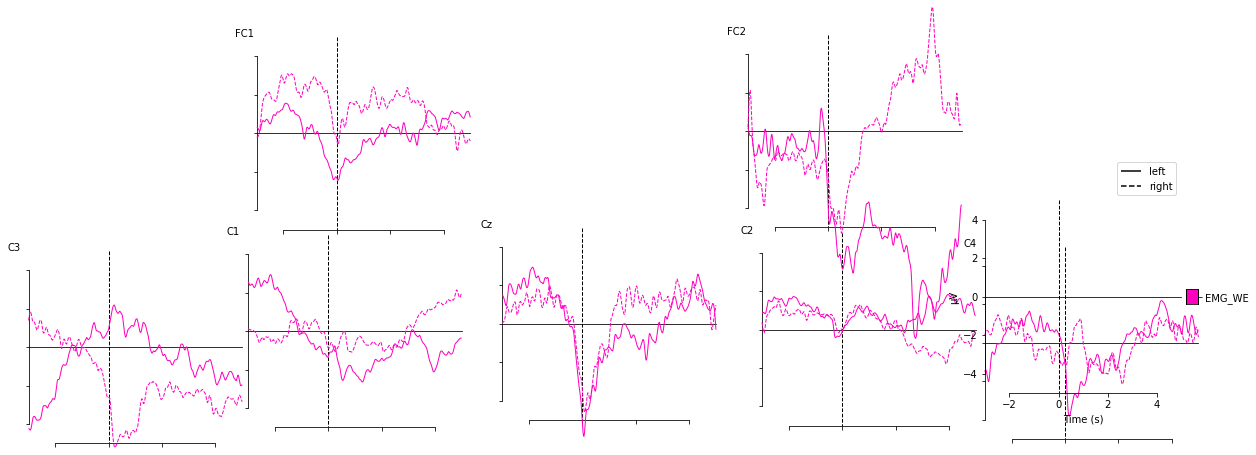

[<Figure size 1296x1008 with 9 Axes>]

In [12]:
# %matplotlib qt
mne.viz.plot_compare_evokeds(lap_WE_evoked_LR, picks='eeg', colors=dict(EMG_WE=0),
                             linestyles=dict(left='solid', right='dashed'),
                             axes='topo', cmap='gist_rainbow',styles=dict(left=dict(linewidth=1),
                                                      right=dict(linewidth=1)), ylim=dict(eeg=[-5, 5]))

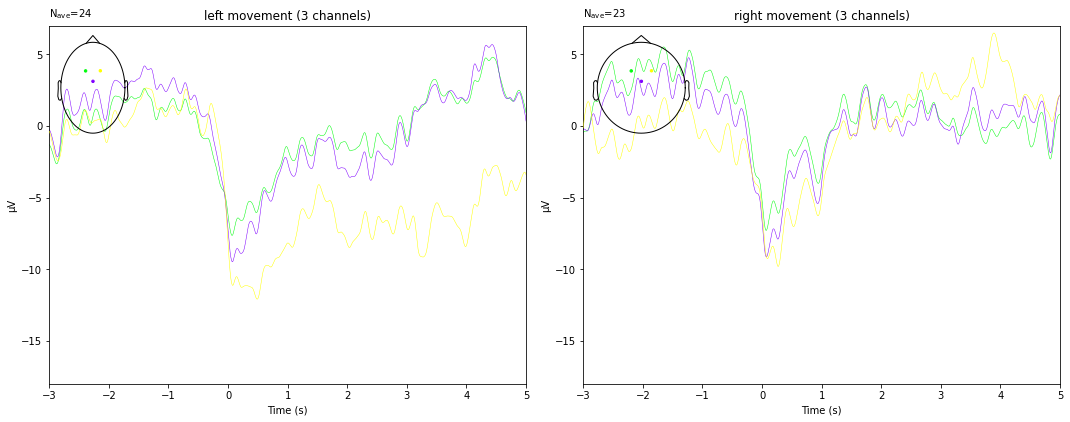

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.subplots_adjust(top=0.6)
# fig.suptitle('no lap', size='xx-large', weight='bold')
WE_evoked_LR['EMG_WE/left'].plot(picks=['FC1', 'Cz', 'FC2'], spatial_colors=True, titles='left movement', axes=axes[0], 
                             ylim=dict(eeg=[-18,7]), show=False);
WE_evoked_LR['EMG_WE/right'].plot(picks=['FC1', 'Cz', 'FC2'], spatial_colors=True, titles='right movement', axes=axes[1], 
                              ylim=dict(eeg=[-18,7]), show=False);

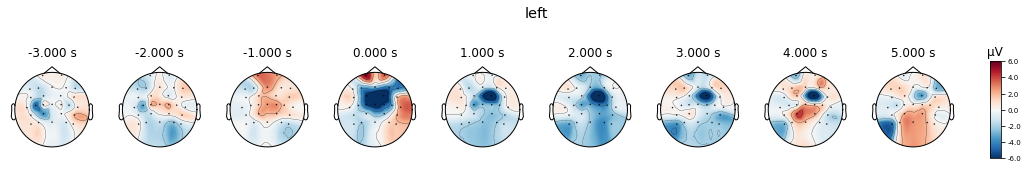

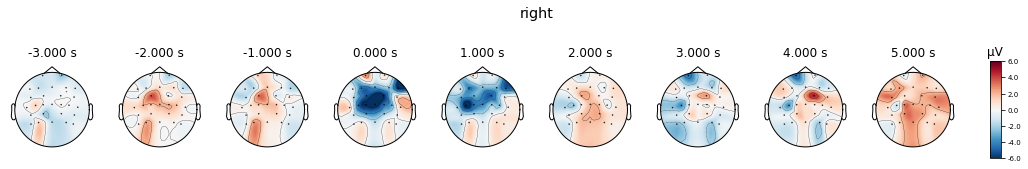

In [14]:
times = np.linspace(-3, 5, 9)
evks['EMG_WE/left'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='left',vmin=topo_vmin, vmax=topo_vmax);
evks['EMG_WE/right'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='right',vmin=topo_vmin, vmax=topo_vmax);

In [17]:
%matplotlib qt
mne.viz.plot_compare_evokeds(WE_evoked_LR, picks='eeg', colors=dict(EMG_WE=0),
                             linestyles=dict(left='solid', right='dashed'),
                             axes='topo', cmap='gist_rainbow',styles=dict(left=dict(linewidth=1),
                                                      right=dict(linewidth=1)), ylim=dict(eeg=[mrcp_min, mrcp_max]))

[<Figure size 1296x1008 with 29 Axes>]

## Index finger extension

In [12]:
included_keys = ['EMG_IE/left', 'EMG_IE/right']
IE_evoked_LR = {k:v for k,v in evks.items() if k in included_keys}
lap_IE_evoked_LR = {k:v for k,v in lap_evks.items() if k in included_keys}

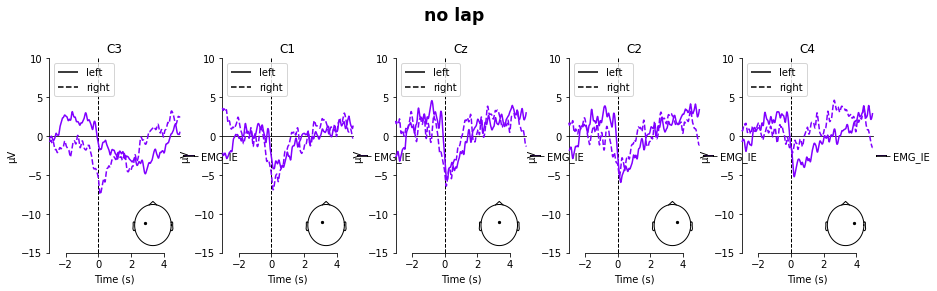

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 4))
fig.subplots_adjust(top=0.8)
fig.suptitle('no lap', size='xx-large', weight='bold')

fig_C3 = mne.viz.plot_compare_evokeds(IE_evoked_LR, picks='C3', colors=dict(EMG_IE=0), 
                             linestyles=dict(left='solid', right='dashed'), 
                             cmap='rainbow', axes=axes[0], show=False,
                             ylim=dict(eeg=[mrcp_min, mrcp_max]))

fig_C1 = mne.viz.plot_compare_evokeds(IE_evoked_LR, picks='C1', colors=dict(EMG_IE=0), 
                             linestyles=dict(left='solid', right='dashed'), 
                             cmap='rainbow', axes=axes[1], show=False,
                             ylim=dict(eeg=[mrcp_min, mrcp_max]))
fig_Cz = mne.viz.plot_compare_evokeds(IE_evoked_LR, picks='Cz', colors=dict(EMG_IE=0),
                             linestyles=dict(left='solid', right='dashed'),
                             cmap='rainbow', axes=axes[2], show=False,
                             ylim=dict(eeg=[mrcp_min, mrcp_max]))

fig_C2 = mne.viz.plot_compare_evokeds(IE_evoked_LR, picks='C2', colors=dict(EMG_IE=0), 
                             linestyles=dict(left='solid', right='dashed'), 
                             cmap='rainbow', axes=axes[3], show=False,
                             ylim=dict(eeg=[mrcp_min, mrcp_max]))
fig_C4 = mne.viz.plot_compare_evokeds(IE_evoked_LR, picks='C4', colors=dict(EMG_IE=0), 
                             linestyles=dict(left='solid', right='dashed'),
                             cmap='rainbow', axes=axes[4], show=False,
                             ylim=dict(eeg=[mrcp_min, mrcp_max]))

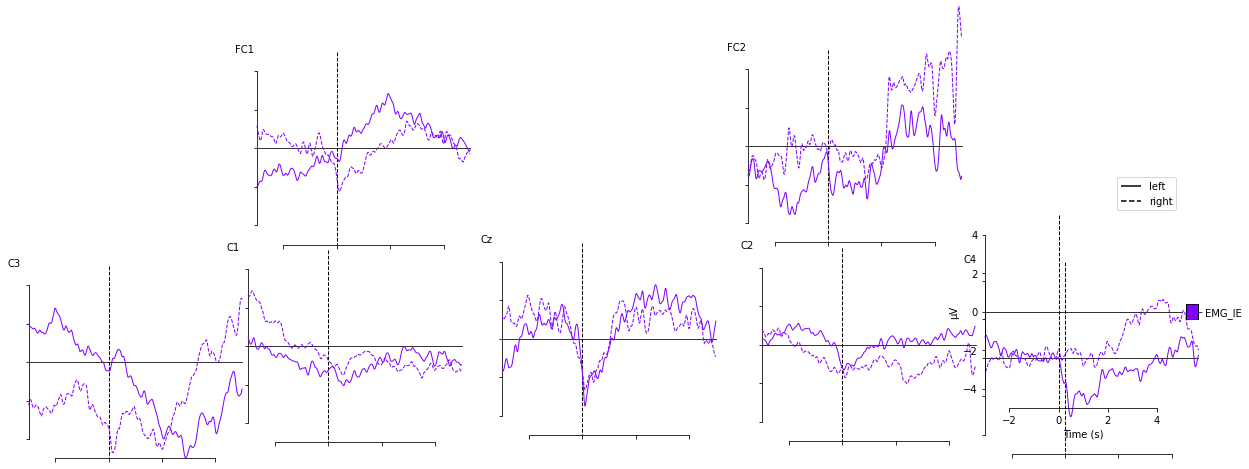

[<Figure size 1296x1008 with 9 Axes>]

In [24]:
mne.viz.plot_compare_evokeds(lap_IE_evoked_LR, picks='eeg', colors=dict(EMG_IE=0),
                             linestyles=dict(left='solid', right='dashed'),
                             axes='topo', cmap='rainbow',styles=dict(left=dict(linewidth=1),
                                                      right=dict(linewidth=1)), ylim=dict(eeg=[-5, 5]))

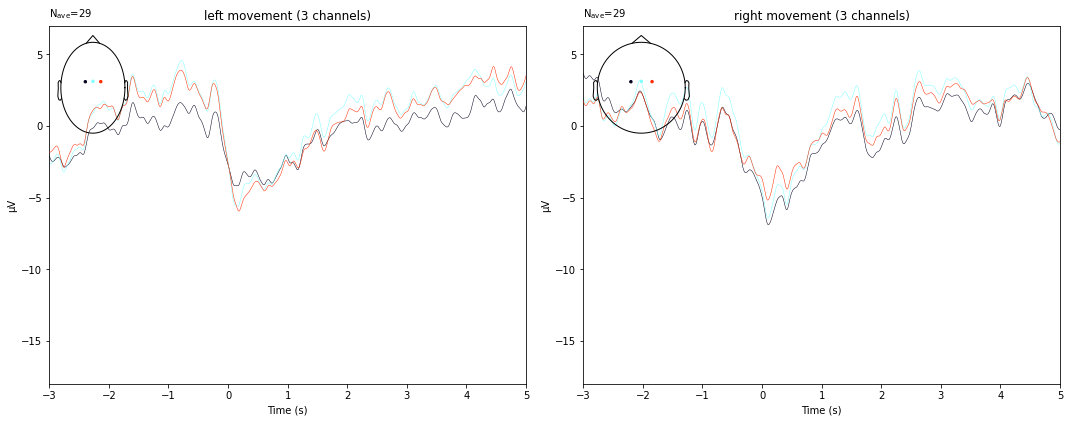

In [25]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
fig.subplots_adjust(top=0.6)
# fig.suptitle('no lap', size='xx-large', weight='bold')
IE_evoked_LR['EMG_IE/left'].plot(picks=['C1', 'Cz', 'C2'], spatial_colors=True, titles='left movement', axes=axes[0], 
                             ylim=dict(eeg=[-18,7]), show=False);
IE_evoked_LR['EMG_IE/right'].plot(picks=['C1', 'Cz', 'C2'], spatial_colors=True, titles='right movement', axes=axes[1], 
                              ylim=dict(eeg=[-18,7]), show=False);

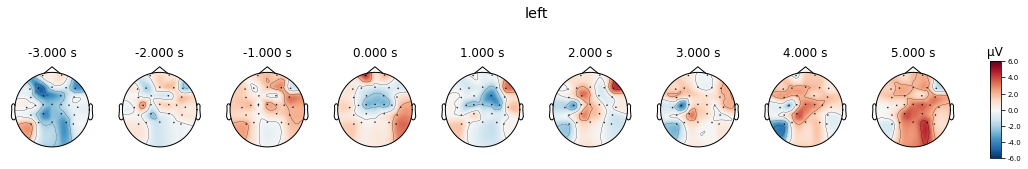

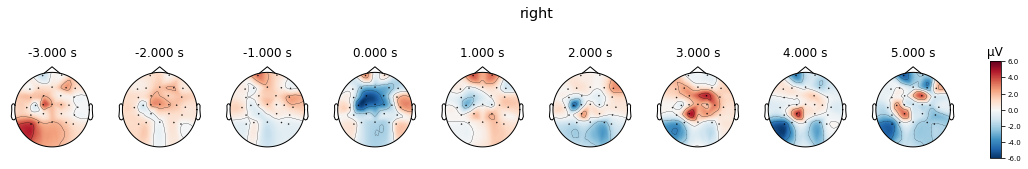

In [26]:
times = np.linspace(-3, 5, 9)
evks['EMG_IE/left'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='left',vmin=topo_vmin, vmax=topo_vmax);
evks['EMG_IE/right'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='right',vmin=topo_vmin, vmax=topo_vmax);

In [15]:
%matplotlib qt
# %matplotlib inline
mne.viz.plot_compare_evokeds(IE_evoked_LR, picks='eeg', colors=dict(EMG_IE=0),
                             linestyles=dict(left='solid', right='dashed'),
                             axes='topo', cmap='rainbow',styles=dict(left=dict(linewidth=1),
                                                      right=dict(linewidth=1)), ylim=dict(eeg=[mrcp_min, mrcp_max]))

[<Figure size 1296x1008 with 29 Axes>]

# Two movements comparison IE vs. WE

## left

In [28]:
included_keys = ['EMG_WE/left', 'EMG_IE/left']
IE_WE_evoked_L = {k:v for k,v in evks.items() if k in included_keys}
lap_IE_WE_evoked_L = {k:v for k,v in lap_evks.items() if k in included_keys}

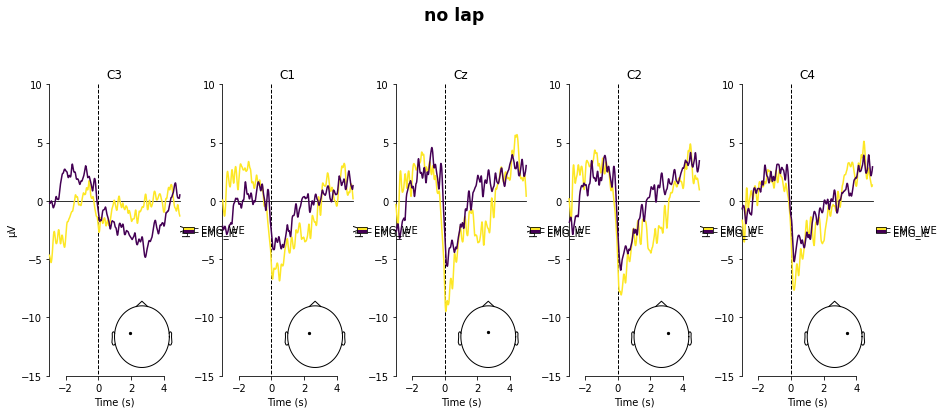

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 6))
fig.subplots_adjust(top=0.8)
fig.suptitle('no lap', size='xx-large', weight='bold')
mne.viz.plot_compare_evokeds(IE_WE_evoked_L, picks='C3', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(left='solid'), cmap='viridis',
                             axes=axes[0], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_L, picks='C1', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(left='solid'), cmap='viridis',
                             axes=axes[1], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_L, picks='Cz', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(left='solid'), cmap='viridis',
                             axes=axes[2], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_L, picks='C2', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(left='solid'), cmap='viridis',
                             axes=axes[3], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_L, picks='C4', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(left='solid'), cmap='viridis',
                             axes=axes[4], show=True, ylim=dict(eeg=[mrcp_min, mrcp_max]))
fig.subplots_adjust(
    left=0.15, right=0.9, bottom=0.01, top=0.9, wspace=0.1, hspace=0.5)

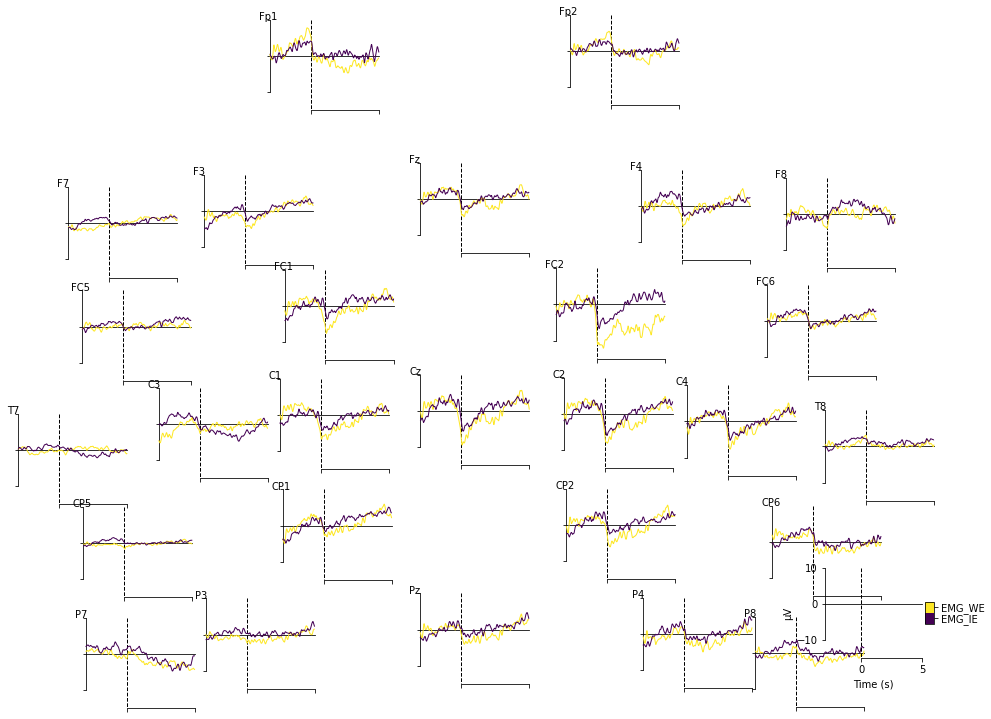

[<Figure size 1296x1008 with 29 Axes>]

In [30]:
mne.viz.plot_compare_evokeds(IE_WE_evoked_L, picks='eeg', colors=dict(EMG_IE=0,EMG_WE=1),
                             linestyles=dict(left='solid'),
                             axes='topo', cmap='viridis',styles=dict(left=dict(linewidth=1),), ylim=dict(eeg=[mrcp_min, mrcp_max]))

#### Lap 

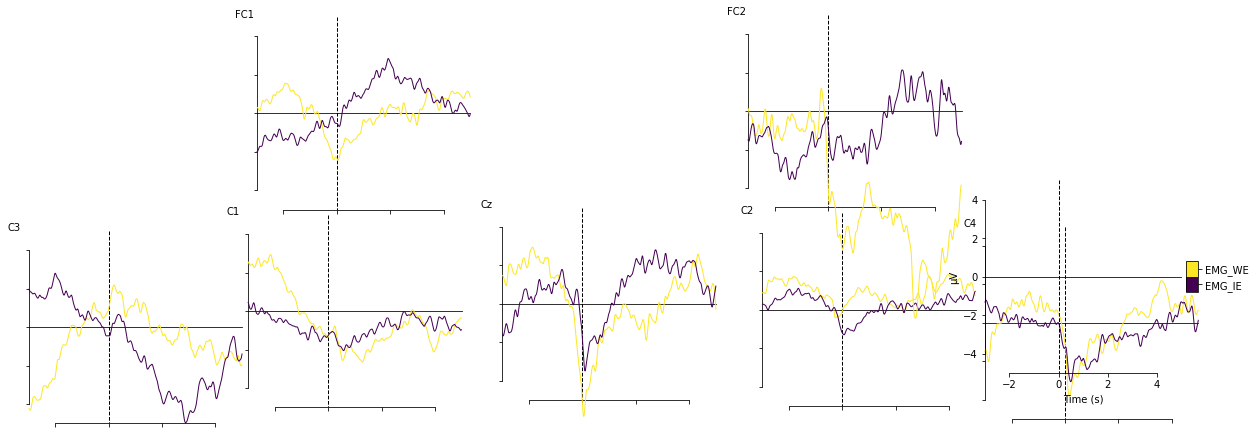

[<Figure size 1296x1008 with 9 Axes>]

In [31]:
mne.viz.plot_compare_evokeds(lap_IE_WE_evoked_L, picks='eeg', colors=dict(EMG_IE=0,EMG_WE=1),
                             linestyles=dict(left='solid'),
                             axes='topo', cmap='viridis',styles=dict(left=dict(linewidth=1),), ylim=dict(eeg=[-5, 5]))

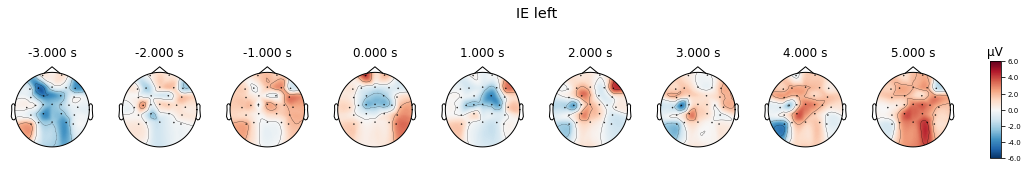

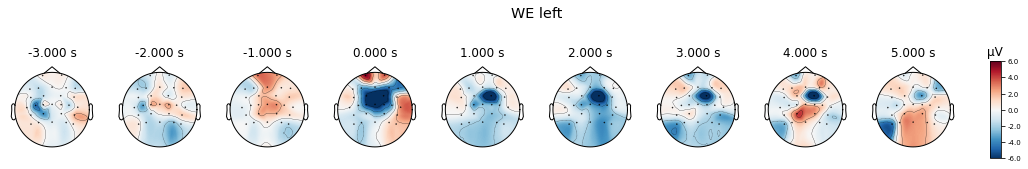

In [32]:
times = np.linspace(-3, 5, 9)
evks['EMG_IE/left'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='IE left',vmin=topo_vmin, vmax=topo_vmax);
evks['EMG_WE/left'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='WE left',vmin=topo_vmin, vmax=topo_vmax);

## right

In [33]:
included_keys = ['EMG_WE/right', 'EMG_IE/right']
IE_WE_evoked_R = {k:v for k,v in evks.items() if k in included_keys}
lap_IE_WE_evoked_R = {k:v for k,v in lap_evks.items() if k in included_keys}

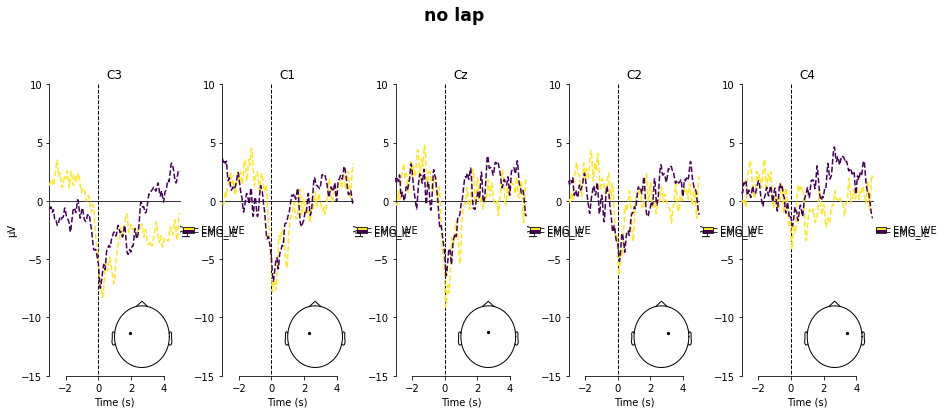

In [34]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 6))
fig.subplots_adjust(top=0.8)
fig.suptitle('no lap', size='xx-large', weight='bold')
mne.viz.plot_compare_evokeds(IE_WE_evoked_R, picks='C3', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(right='dashed'), cmap='viridis',
                             axes=axes[0], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_R, picks='C1', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(right='dashed'), cmap='viridis',
                             axes=axes[1], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_R, picks='Cz', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(right='dashed'), cmap='viridis',
                             axes=axes[2], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_R, picks='C2', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(right='dashed'), cmap='viridis',
                             axes=axes[3], show=False, ylim=dict(eeg=[mrcp_min, mrcp_max]))
mne.viz.plot_compare_evokeds(IE_WE_evoked_R, picks='C4', 
                             colors=dict(EMG_IE=0,EMG_WE=1), 
                             linestyles=dict(right='dashed'), cmap='viridis',
                             axes=axes[4], show=True, ylim=dict(eeg=[mrcp_min, mrcp_max]))
fig.subplots_adjust(
    left=0.15, right=0.9, bottom=0.01, top=0.9, wspace=0.1, hspace=0.5)

[<Figure size 1296x1008 with 29 Axes>]

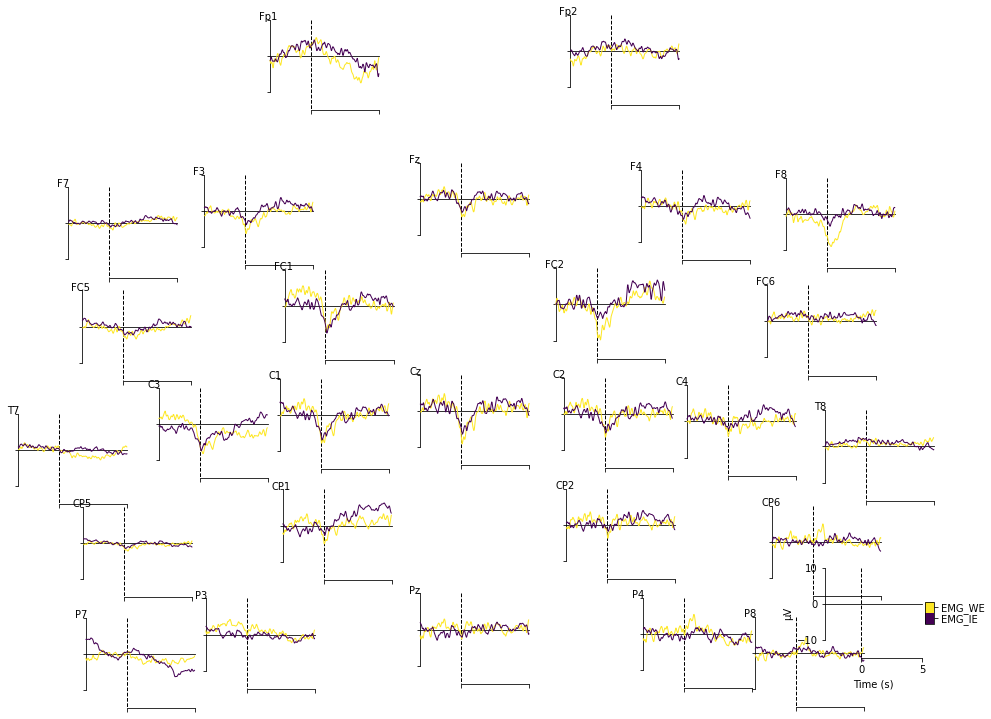

In [35]:
%matplotlib qt
mne.viz.plot_compare_evokeds(IE_WE_evoked_R, picks='eeg', colors=dict(EMG_IE=0,EMG_WE=1),
                             linestyles=dict(right='solid'),
                             axes='topo', cmap='viridis',styles=dict(right=dict(linewidth=1),), ylim=dict(eeg=[mrcp_min, mrcp_max]))

#### Lap 

[<Figure size 1296x1008 with 9 Axes>]

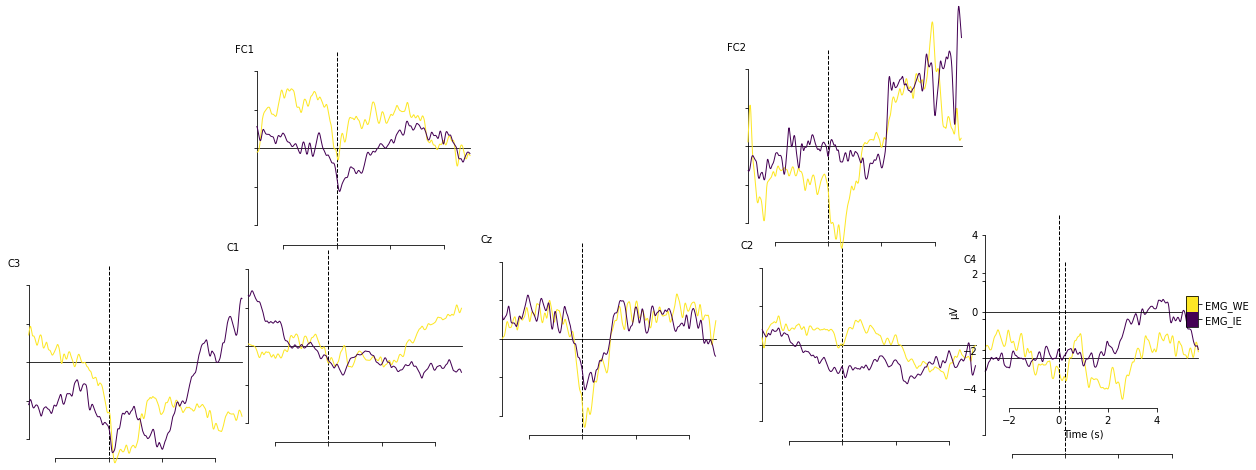

In [36]:
mne.viz.plot_compare_evokeds(lap_IE_WE_evoked_R, picks='eeg', colors=dict(EMG_IE=0,EMG_WE=1),
                             linestyles=dict(right='solid'),
                             axes='topo', cmap='viridis',styles=dict(right=dict(linewidth=1),), ylim=dict(eeg=[-5, 5]))

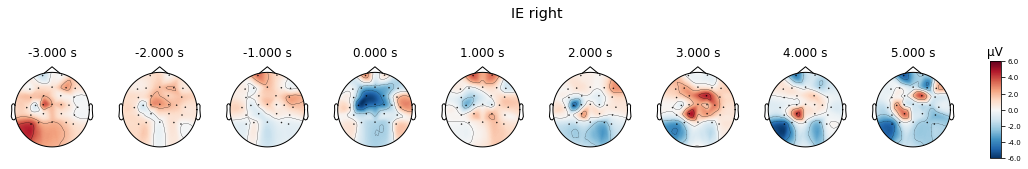

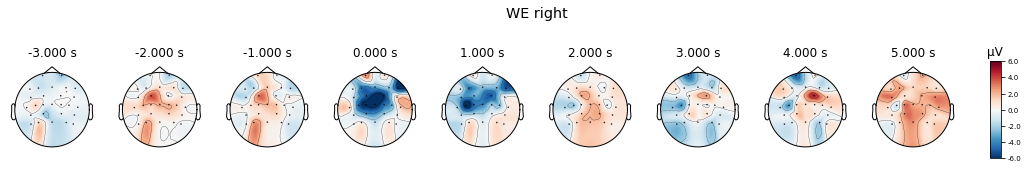

In [37]:
times = np.linspace(-3, 5, 9)
evks['EMG_IE/right'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='IE right',vmin=topo_vmin, vmax=topo_vmax);
evks['EMG_WE/right'].plot_topomap(ch_type='eeg', times=times, colorbar=True, title='WE right',vmin=topo_vmin, vmax=topo_vmax);